# Модуль 1. Алгоритмы на основе деревьев решений

## Деревья решений. Алгоритм CART

**CART (Classification and Regression Tree)** - алгоритм и предназначенный для построения бинарных деревьев решений (деревьев, у которых каждая вершина связана с двумя другими вершинами нижнего уровня). Алгоритм очень похож на C4.5, однако в отличие от последнего предназначен как для задач классификации, так и для задач регрессии. CART важен для нас поскольку, именно он используется для построения моделей решающих деревьев в sklearn.


## 3/10   Алгоритм CART: параметры разбиения

В качестве **резюме** приведём наш оптимизированный алгоритм определения пороговых значений для фактора $x_j$:

1. Отсортировать числовой фактор $x_j$ по возрастанию:

$\{x_{ij}\ \mid \ x_{ij}<x_{(i+1)j}\}$

2. Вычислить среднее между двумя соседними уникальными значениями фактора:

${{\{x}_{ij}}^{mean} \mid {{\ x}_{ij}}^{mean}=\frac{x_{ij}+x_{(i+1)j}}{2}\}$

3. В качестве кандидатов на пороговые значений  выбираются только те значения, при которых целевой признак меняет своё значение:

${\{x_{ij}}^{mean} \mid \ y_i-y_{(i+1)}\neq 0\}$



Воспользуемся данными о недвижимости в штате Айова из Ames Housing Dataset. Это классическая задача предсказания цены недвижимости.

Для примера визуализации из всех признаков, описывающих объекты недвижимости, мы выберем:

Lot_Frontage — ширина фасада;
Lot_Area — площадь объекта недвижимости.
Необходимо предсказать стоимость недвижимости (Sale_Price). Файл с данными вы можете скачать здесь.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree

Примечание. Для более понятной визуализации перед построением дерева уберём из датасета объекты с Lot_Frontage > 150 и с Lot_Area > 20000.

In [2]:
# Создаём обучающую выборку
ames_data = pd.read_csv('data/AmesHousing.csv')
ames_data = ames_data[(ames_data['Lot Frontage'] <=150) & (ames_data['Lot Area'] <=20000)]
X = ames_data[['Lot Frontage', 'Lot Area']]
y = ames_data['SalePrice']

In [3]:
# Инициализируем модель дерева решений с максимальной глубиной 3 и обучаем её
dt_reg = tree.DecisionTreeRegressor(max_depth=3)
dt_reg.fit(X.values, y)

DecisionTreeRegressor(max_depth=3)

Отследить, как дерево решений строит свой прогноз, нам может помочь граф обученного дерева решений. Напомним, что за его визуализацию в библиотеке sklearn отвечает функция plot_tree() из модуля tree.

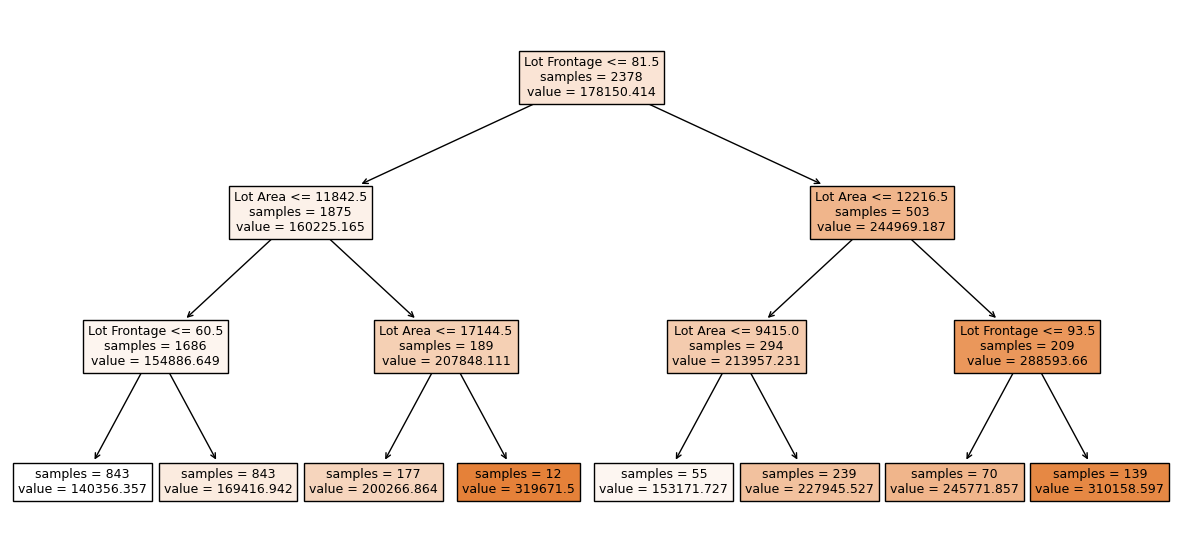

In [4]:
# Визуализируем дерево решений в виде графа
fig = plt.figure(figsize=(15, 7))
tree_graph = tree.plot_tree(
    dt_reg, #дерево решений 
    feature_names=list(X.columns), #имена факторов
    filled=True, #расцветка
    impurity=False, #отображать ли неоднородность
);

Построим диаграмму рассеяния и визуализируем то, как дерево решений разделяет пространство факторов на прямоугольные области. Для этого шага мы реализовали функцию plot_decision_bound_regression():

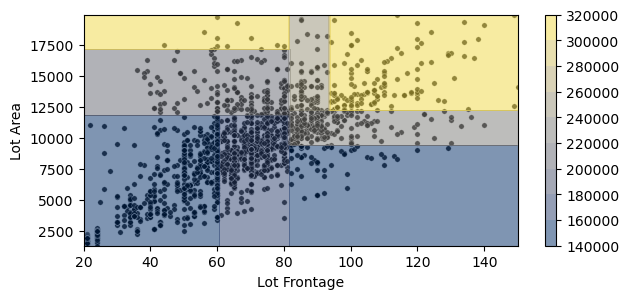

In [5]:
def plot_decision_bound_regression(X, y, model, fig):
    xx1, xx2 = np.meshgrid(
        np.arange(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 1),
        np.arange(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 1)
    )
    X_net = np.hstack([xx1.reshape(-1, 1), xx2.reshape(-1, 1)])
    y_pred = model.predict(X_net)
    y_pred = y_pred.reshape(xx1.shape)
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], s=15, color='black', alpha=0.8)
    contour = plt.contourf(xx1, xx2, y_pred, 10, cmap='cividis', alpha=0.5)
    fig.colorbar(contour)

# Визуализируем разделяющую поверхность дерева решений
fig = plt.figure(figsize = (7, 3))
plot_decision_bound_regression(X, y, dt_reg, fig)

Что мы здесь видим? В результате построения дерева решений было образовано восемь областей ($R_1, R_2,..., R_8$), соответствующих каждому из восьми листьев. В каждой из областей было рассчитано предсказание дерева для этой области  — среднее арифметическое целевой переменной  (они отражены на тепловой шкале справа от диаграммы) по формуле, приведённой выше.

Прогноз для нового объекта будет определяться в зависимости от того, в какую из полученных областей он попадёт.

In [6]:
# Создаём обучающую выборку    
bill_data = pd.read_csv('data/bill_authentication.csv')
X = bill_data[['Variance', 'Skewness']]
y = bill_data['Class']

In [7]:
# Инициализируем модель дерева решений с максимальной глубиной 4 и обучаем её
dt_clf = tree.DecisionTreeClassifier(max_depth=4)
dt_clf.fit(X.values, y)

DecisionTreeClassifier(max_depth=4)

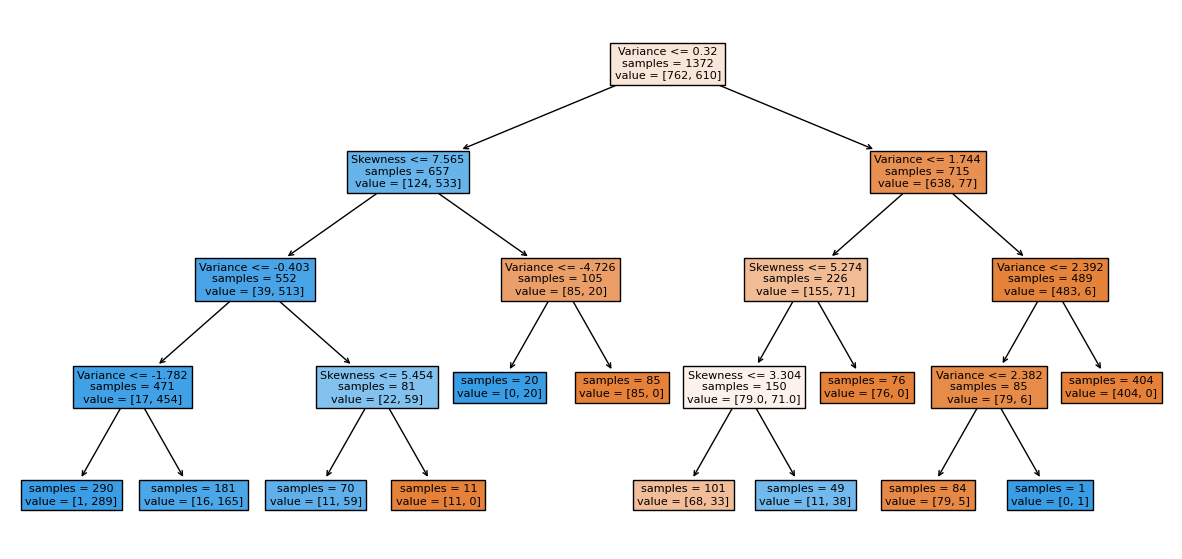

In [8]:
# Визуализируем дерево решений в виде графа
fig = plt.figure(figsize=(15, 7))
tree_graph = tree.plot_tree(
    dt_clf, #дерево решений
    feature_names=list(X.columns), #имена факторов
    filled=True, #расцветка
    impurity=False, #отображать ли неоднородность
);

В результате построения дерева было образовано 12 областей (), каждая из которых соответствует одному из 12 листьев. В каждой из областей была рассчитана оценка вероятности принадлежности к каждому из классов — . Класс объекта  определяется как класс с максимальной из этих вероятностей.

Построим диаграмму рассеяния и визуализируем то, как дерево решений разделяет пространство факторов на прямоугольные области. Для этого шага мы реализовали функцию plot_decision_bound_classification():

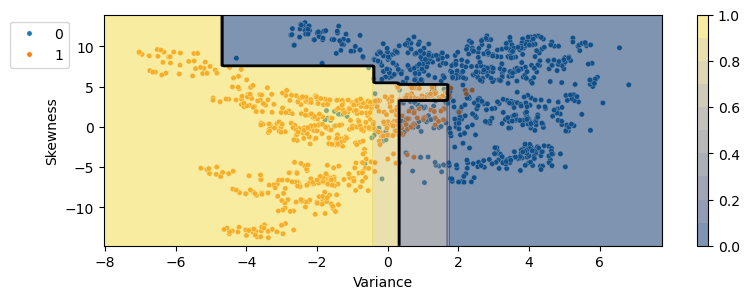

In [9]:
def plot_decision_bound_classification(X, y, model, fig):
    xx1, xx2 = np.meshgrid(
        np.arange(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 0.1),
        np.arange(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 0.1)
    )
    X_net = np.hstack([xx1.reshape(-1, 1), xx2.reshape(-1, 1)])
    probs = model.predict_proba(X_net)[:, 1]
    probs = probs.reshape(xx1.shape)
    
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=y, s=15, alpha=1)
    contour = plt.contourf(xx1, xx2, probs, 10, cmap='cividis', alpha=0.5)
    bound = plt.contour(xx1, xx2, probs, [0.5], linewidths=2, colors='black');
    fig.colorbar(contour)
    plt.legend(bbox_to_anchor=(-0.05, 1))
# Визуализируем разделяющую поверхность дерева решений
fig = plt.figure(figsize = (9, 3))
plot_decision_bound_classification(X, y, dt_clf, fig)

**Задание 3.4**

Дана часть датасета о домах в штате Айова, состоящая из 15 наблюдений:

In [10]:
import pandas as pd

ames_data = pd.read_csv('data/AmesHousing.csv')
ames_data = ames_data[(ames_data['Lot Frontage'] <=150) & (ames_data['Lot Area'] <=20000)]
ames_sample = ames_data[['Lot Frontage', 'Lot Area', 'SalePrice']].sample(
    n=15, #количество объектов
    random_state=42, #генератор случайных чисел
    ignore_index=True #сбрасываем счетчик индекса
)

Найдите уникальных кандидатов на пороговое значение  для фактора  (Lot Frontage).

Выберите верный вариант ответа:

In [11]:
data = ames_sample
x = data['Lot Frontage']
y = data['SalePrice']

# сортируем и удаляем дубликаты
x = x.sort_values().drop_duplicates()

x_roll_mean = x.rolling(2).mean()
x_roll_mean = x_roll_mean.dropna()

y = y[x_roll_mean.index]
y_roll_mean = y.diff()

candidates = x_roll_mean[y_roll_mean != 0]
candidates

8      53.0
0      58.0
14     61.0
2      65.0
9      69.0
7      71.0
5      76.0
4      86.0
1      94.0
12    101.0
Name: Lot Frontage, dtype: float64

**Задание 3.5**

Для части датасета о домах в Айове из предыдущего задания найдите уникальных кандидатов на пороговое значение  для фактора  (Lot Area).

Выберите верный вариант ответа:

In [12]:
data = ames_sample
x = data['Lot Area']
y = data['SalePrice']

# сортируем и удаляем дубликаты
x = x.sort_values().drop_duplicates()

x_roll_mean = x.rolling(2).mean()
x_roll_mean = x_roll_mean.dropna()

y = y[x_roll_mean.index]
y_roll_mean = y.diff()

candidates = x_roll_mean[y_roll_mean != 0]
candidates

8      5508.0
6      7153.0
14     7425.0
13     7949.0
12     8405.5
7      8526.5
3      8850.0
4      9137.5
2      9466.0
5     10051.5
1     10507.0
0     10834.0
11    11365.0
9     12288.0
Name: Lot Area, dtype: float64

## 4/10   Алгоритм CART: неоднородность, критерии информативности

**Задание 4.3**

Дана часть датасета о домах в штате Айова, состоящая из 15 наблюдений:

In [50]:
ames_data = ames_data[(ames_data["Lot Frontage"] <=150) & (ames_data["Lot Area"] <=20000)]

ames_sample = ames_data[["Lot Frontage", "Lot Area", "SalePrice"]].sample(
    n=15, random_state=42, ignore_index=True
)

X = ames_sample[["Lot Frontage", "Lot Area"]]
y = ames_sample["SalePrice"]

Найдите оптимальные для построения решающего пня параметры разбиения $j$ и $t$. В качестве критерия информативности используйте квадратичную ошибку.

Примечание. Для самопроверки обучите на данной части датасета дерево решений из sklearn с максимальной глубиной 1, критерием информативности 'squared_error' и параметром random_state = 0 и визуализируйте его граф.

In [51]:
# Форматирование всех столбцов с помощью функции
ames_sample.style.format(lambda x: f'{x:,.0f}')

# Форматирование отдельных столбцов с помощью словаря
# df.style.format({'A': lambda x: f'{x:.2f}', 'B': lambda x: f'{x:.3f}'})

,Lot Frontage,Lot Area,SalePrice
0,60,"11,040","108,000"
1,96,"10,628","193,000"
2,68,"9,717","142,125"
3,50,"9,060","150,909"
4,92,"9,215","204,500"
5,80,"10,386","305,900"
6,60,"7,350","139,000"
7,72,"8,640","229,800"
8,56,"6,956","97,900"
9,70,"12,886","175,000"


In [52]:
ames_sample

,Lot Frontage,Lot Area,SalePrice
0,60.0,11040,108000
1,96.0,10628,193000
2,68.0,9717,142125
3,50.0,9060,150909
4,92.0,9215,204500
5,80.0,10386,305900
6,60.0,7350,139000
7,72.0,8640,229800
8,56.0,6956,97900
9,70.0,12886,175000


In [53]:
x = ames_sample["Lot Frontage"]
x.sort_values()

3      50.0
8      56.0
10     56.0
13     56.0
0      60.0
6      60.0
14     62.0
2      68.0
9      70.0
7      72.0
5      80.0
4      92.0
1      96.0
11     96.0
12    106.0
Name: Lot Frontage, dtype: float64

In [54]:
x = ames_sample["Lot Area"]
x.sort_values()

10     4060
8      6956
6      7350
14     7500
13     8398
12     8413
7      8640
3      9060
4      9215
2      9717
5     10386
1     10628
0     11040
11    11690
9     12886
Name: Lot Area, dtype: int64

In [55]:
y.sort_values()

8      97900
10     99900
0     108000
6     139000
2     142125
13    144100
3     150909
9     175000
14    176000
1     193000
4     204500
11    207000
7     229800
5     305900
12    312500
Name: SalePrice, dtype: int64

In [56]:
def find_candidates_for_thresholds(x, y):
    x = x.sort_values().drop_duplicates()
    x_roll_mean = x.rolling(2).mean().dropna()
    y = y[x_roll_mean.index]
    y_roll_mean = y.diff()
    candidates = x_roll_mean[y_roll_mean != 0]
    return candidates.values

In [57]:
data = ames_sample
print(find_candidates_for_thresholds(data['Lot Frontage'], data['SalePrice']))
print(find_candidates_for_thresholds(data['Lot Area'], data['SalePrice']))

[ 53.  58.  61.  65.  69.  71.  76.  86.  94. 101.]
[ 5508.   7153.   7425.   7949.   8405.5  8526.5  8850.   9137.5  9466.
 10051.5 10507.  10834.  11365.  12288. ]


Для начала создадим функцию для расчёта среднего квадрата ошибки — squared_error(). Она будет принимать на вход истинные ответы и возвращать значение MSE, рассчитанное для входных данных.

In [58]:
def squared_error(y):
    y_pred = y.mean()
    return ((y - y_pred) ** 2).mean()

In [59]:
y

0     108000
1     193000
2     142125
3     150909
4     204500
5     305900
6     139000
7     229800
8      97900
9     175000
10     99900
11    207000
12    312500
13    144100
14    176000
Name: SalePrice, dtype: int64

In [60]:
squared_error(y)

4066908207.262222

Далее нам необходимо реализовать функцию split(), которая разбивает выборку  по предикату  с параметрами разделения (split_params) на левую и правую части:

In [61]:
def split(X, y, split_params):
    j, t = split_params
    predicat = X.iloc[:, j] <= t
    X_left, y_left = X[predicat], y[predicat]
    X_right, y_right = X[~predicat], y[~predicat]
    return X_left, y_left, X_right, y_right

In [62]:
split_params = [0, 71]

In [63]:
split(X, y, split_params)

(    Lot Frontage  Lot Area
 0           60.0     11040
 2           68.0      9717
 3           50.0      9060
 6           60.0      7350
 8           56.0      6956
 9           70.0     12886
 10          56.0      4060
 13          56.0      8398
 14          62.0      7500,
 0     108000
 2     142125
 3     150909
 6     139000
 8      97900
 9     175000
 10     99900
 13    144100
 14    176000
 Name: SalePrice, dtype: int64,
     Lot Frontage  Lot Area
 1           96.0     10628
 4           92.0      9215
 5           80.0     10386
 7           72.0      8640
 11          96.0     11690
 12         106.0      8413,
 1     193000
 4     204500
 5     305900
 7     229800
 11    207000
 12    312500
 Name: SalePrice, dtype: int64)

Затем создадим функцию calculate_weighted_impurity(). Она будет принимать на вход выборку — X и y, параметры разбиения — split_params, а также criterion — функцию, по которой рассчитывается критерий информативности (у нас это функция squared_error()). Результатом работы функции будет взвешенная неоднородность после разбиения.

In [64]:
criterion = squared_error

In [65]:
def calculate_weighted_impurity(X, y, split_params, criterion):
    X_left, y_left, X_right, y_right = split(X, y, split_params)
    N, N_left, N_right  = y.size, y_left.size, y_right.size
    score = N_left / N * criterion(y_left) + N_right / N * criterion(y_right)
    return score

In [66]:
calculate_weighted_impurity(X, y, split_params, criterion)

1414654917.0222223

Наконец, финальный шаг — построить решающий пень. Для этого необходимо оформить в виде цикла отбор кандидатов в параметры разбиения и найти оптимальные из них. За данный шаг будет отвечать функция best_split(). Она будет принимать на вход выборку (X и y) и возвращать оптимальные параметры разбиения, при которых значение взвешенной неоднородности минимально, а также значение этой неоднородности.

In [67]:
def best_split(X, y, criterion):
    M = X.shape[1]
    min_weighted_impurity = np.inf
    optimal_split_params = None
    for j in range(M):
        thresholds = find_candidates_for_thresholds(X.iloc[:, j], y)
        for t in thresholds:
            split_params = (j, t)
            weighted_impurity = calculate_weighted_impurity(X, y, split_params, criterion)
            if weighted_impurity < min_weighted_impurity:
                min_weighted_impurity = weighted_impurity
                optimal_split_params = split_params
    return optimal_split_params

In [68]:
optimal_params = best_split(X, y, criterion)
optimal_params

(0, 71.0)

In [69]:
X.columns

Index(['Lot Frontage', 'Lot Area'], dtype='object')

1. На основе какого фактора  будет построено решающее правило в корневой вершине?

2. Чему равно оптимальное пороговое значение ? Ответ приведите в виде целого числа.

**Ответ:** Lot Frontage, 71.0

3. Чему равно значение взвешенной неоднородности после разбиения при найденных оптимальных параметрах сплита? Ответ округлите до целого числа.

In [71]:
calculate_weighted_impurity(X, y, optimal_params, criterion)

1414654917.0222223

Примечание. При выполнении поиска оптимальных параметров сплита возможно возникновение такой ситуации, когда взвешенная неоднородность для двух разных наборов параметров будет одинаковой. В нашей реализации такие ситуации не учитываются: выбирается первый встретившийся вариант параметров с наименьшей взвешенной неоднородностью.

В sklearn такие случаи обрабатываются следующим образом: из всех наборов параметров разбиения, для которых неоднородность после сплита минимальна из возможных и при этом одинакова, случайным образом выбирается только один этих наборов. Поэтому иногда деревья, полученные с помощью нашего кода, и деревья из sklearn могут не совпадать. Для получения этого совпадения при работе с деревьями из sklearn необходимо задать параметр random_state. Мы будем указывать это в явном виде при формулировании заданий.

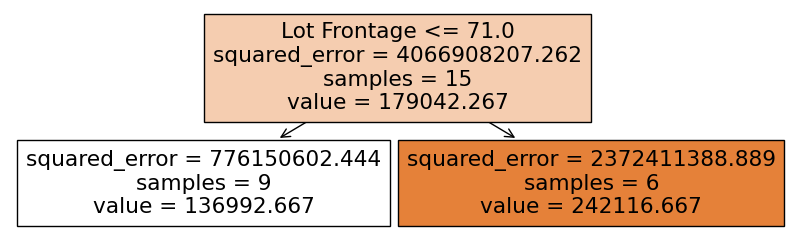

In [72]:
# Инициализируем модель дерева решений с максимальной глубиной 1 и обучаем её
dt_reg = tree.DecisionTreeRegressor(max_depth=1, criterion='squared_error', random_state=0)
dt_reg.fit(X.values, y)

# Визуализируем дерево решений в виде графа
fig = plt.figure(figsize=(10, 3))
tree_graph = tree.plot_tree(
    dt_reg, #дерево решений 
    feature_names=list(X.columns), #имена факторов
    filled=True, #расцветка
    impurity=True, #отображать ли неоднородность
);

Реализуем функцию entropy(), которая рассчитывает энтропию Шеннона. На вход функции приходит целевая переменная . Далее с помощью функции value_counts() считаются доли каждого из классов — вероятности принадлежности к классам. Затем эти вероятности логарифмируются по основанию , и наконец по приведённой выше формуле рассчитывается энтропия.


In [73]:
def entropy(y):
    p = y.value_counts(normalize=True)
    entropy = -np.sum(p * np.log2(p))
    return entropy

In [74]:
optimal_params = best_split(X, y, criterion=entropy)
optimal_params

(0, 65.0)

**Задание 4.5**

Дана часть датасета о банкнотах, состоящая из 15 наблюдений:

In [75]:
bill_data = pd.read_csv('data/bill_authentication.csv')
bill_sample = bill_data[['Variance', 'Skewness', 'Class']].sample(
    n=15, 
    random_state=42, 
    ignore_index=True
)
# Создаём обучающую выборку
X = bill_sample[['Variance', 'Skewness']]
y = bill_sample['Class']

Найдите оптимальные для построения решающего пня параметры разбиения $j$ и $t$. Для этого воспользуйтесь функцией best_split(), которую мы реализовали ранее. В качестве критерия информативности используется энтропию Шеннона.

In [76]:
optimal_params = best_split(X, y, criterion=entropy)
optimal_params

(1, 3.22085)

In [77]:
calculate_weighted_impurity(X, y, optimal_params, criterion=entropy)

0.45977313014931737

Примечание. Для самопроверки обучите на данной части датасета дерево решений из sklearn с максимальной глубиной 1, критерием информативности 'entropy' и параметром random_state = 0 и визуализируйте его граф.

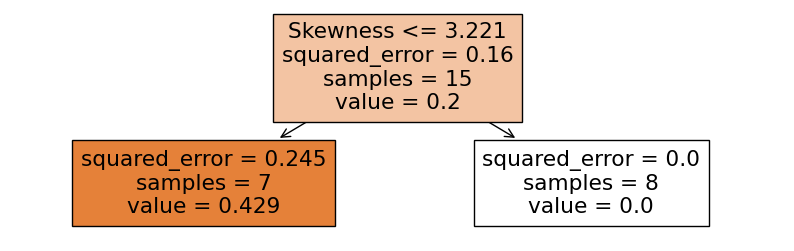

In [78]:
# Инициализируем модель дерева решений с максимальной глубиной 1 и обучаем её
dt_reg = tree.DecisionTreeRegressor(max_depth=1, criterion='squared_error', random_state=0)
dt_reg.fit(X.values, y)

# Визуализируем дерево решений в виде графа
fig = plt.figure(figsize=(10, 3))
tree_graph = tree.plot_tree(
    dt_reg, #дерево решений 
    feature_names=list(X.columns), #имена факторов
    filled=True, #расцветка
    impurity=True, #отображать ли неоднородность
);

## 5/10   Алгоритм CART: рекурсия, критерии остановки


In [79]:
class Node:
    def __init__(self, left=None, 
                 right=None, value=None, 
                 split_params=None, impurity=None,
                 samples=None, is_leaf=False):
        self.left = left
        self.right = right
        self.split_params = split_params
        self.value = value
        self.impurity = impurity
        self.samples = samples
        self.is_leaf = is_leaf

Для случая задачи классификации ответ — это класс с наибольшей вероятностью, иначе говоря, самый популярный класс. Мы знаем, что самое популярное значение — это мода, а в Pandas как раз есть функция, которая позволяет вычислять её в одну строку кода, — mode(). Помним, что мод может быть несколько — нам нужна любая из них, поэтому мы берём первое значение из списка.

Реализуем эту часть в виде функции create_leaf_prediction(). Она будет принимать на вход целевую переменную y и возвращать модальное значение:

In [80]:
def create_leaf_prediction(y):
    value = y.mode()[0]
    return value

Далее введём критерий остановки. Самый базовый критерий — равенство нулю критерия информативности, рассчитанного по вершине.

In [81]:
def stopping_criterion(X, y, criterion):
    return criterion(y) == 0

Наконец, создадим функцию build_decision_tree(). Она будет реализовывать сам рекурсивный алгоритм построения дерева решений. Функция будет принимать на вход выборку X и y, а также критерий информативности. На выходе функции должна быть корневая вершина дерева (объект класса Node). Она будет ссылаться на своих левого и правого потомка, они в свою очередь будут ссылаться на своих потомков, и так далее до самых листьев.

In [82]:
def build_decision_tree(X, y, criterion):
    if stopping_criterion(X, y, criterion):
        value = create_leaf_prediction(y)
        node = Node(
            value=value, 
            impurity=criterion(y), 
            samples=y.size,
            is_leaf=True
        )
    else:
        split_params = best_split(X, y, criterion=criterion)
        X_left, y_left, X_right, y_right = split(X, y, split_params)
        left = build_decision_tree(X_left, y_left, criterion)
        right = build_decision_tree(X_right, y_right, criterion)       
        node = Node(
            left=left, right=right, 
            split_params=split_params, 
            impurity=criterion(y), 
            samples=y.size
        )
    
    return node

Также напишем вспомогательную функцию print_decision_tree(). Она будет принимать на вход корневую вершину дерева решений и рекурсивно выводить дерево решений в виде текста:

In [83]:
def print_decision_tree(node, depth=0):
    depth += 1
    if node.is_leaf:
        print('   ' * depth, 'class: {}'.format(node.value))
    else:
        print('   ' * depth, 'feature_{} <= {:.3f}:'.format(*node.split_params))
        print_decision_tree(node.left, depth=depth)
        print('   ' * depth, 'feature_{} > {:.3f}:'.format(*node.split_params))
        print_decision_tree(node.right, depth=depth)

In [84]:
# Создаём обучающую выборку
data = pd.DataFrame({
    'age': [17, 64, 18, 20, 38, 49, 55, 25, 29, 31],
    'income': [25, 80, 22, 36, 37, 59, 74, 70, 33, 102],
    'loan': [1, 0, 1, 0, 1, 0, 0, 1, 1, 0]
})
X = data[['age', 'income']]
y = data['loan']

# Строим дерево решений и выводим его на экран
decision_tree = build_decision_tree(X, y, criterion=entropy)
print_decision_tree(decision_tree)

    feature_0 <= 43.500:
       feature_1 <= 86.000:
          feature_0 <= 22.500:
             feature_0 <= 19.000:
                class: 1
             feature_0 > 19.000:
                class: 0
          feature_0 > 22.500:
             class: 1
       feature_1 > 86.000:
          class: 0
    feature_0 > 43.500:
       class: 0


Давайте сравним наш результат с деревом решений из sklearn, напечатав его в текстовом виде с помощью функции export_text() из модуля tree. Не будем ограничивать глубину дерева, а в качестве значения параметра random_state возьмём 1000 для совпадения результатов:

In [85]:
# Создаём модель дерева решений
dt = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий информативности
    random_state=1000 #генератор случайных чисел
)
dt.fit(X, y)
# Выводим дерево решений на экран в виде списка условий
print(tree.export_text(decision_tree=dt))

|--- feature_0 <= 43.50
|   |--- feature_1 <= 86.00
|   |   |--- feature_0 <= 22.50
|   |   |   |--- feature_0 <= 19.00
|   |   |   |   |--- class: 1
|   |   |   |--- feature_0 >  19.00
|   |   |   |   |--- class: 0
|   |   |--- feature_0 >  22.50
|   |   |   |--- class: 1
|   |--- feature_1 >  86.00
|   |   |--- class: 0
|--- feature_0 >  43.50
|   |--- class: 0



Как вы понимаете, построить дерево решений мало — нужно ещё научить его предсказывать целевую переменную для новых объектов. Для этого реализуем две функции:

```predict_sample()``` принимает на вход вершину и один объект из выборки ```x```. Алгоритм предсказания следующий: нужно рекурсивно передвигаться по дереву на основе характеристик объекта (если $x[j] \leq t$ — в левую вершину, иначе — в правую), а когда дойдём до листовой вершины, вернуть предсказание, которое присвоено этому листу (```value```).

In [86]:
def predict_sample(node, x):
    if node.is_leaf:
        return node.value
    j, t = node.split_params
    if x[j] <= t:
        return predict_sample(node.left, x)
    else:
        return predict_sample(node.right, x)

```predict()``` принимает на вход дерево решений и матрицу из объектов X, для которых нужно сделать предсказание. Внутри себя функция должна сделать предсказание для всех объектов из X — вызвать функцию ```predict_sample()```. Результат оборачивается в список, а затем в *numpy*-вектор.

In [87]:
def predict(decision_tree, X):
    predictions = [predict_sample(decision_tree, x) for x in X.values]
    return np.array(predictions)

In [89]:
# Предсказываем целевую переменную
y_pred = predict(decision_tree, X)
print('Predictions: {}'.format(y_pred))
# Predictions: [1 0 1 0 1 0 0 1 1 0]

Predictions: [1 0 1 0 1 0 0 1 1 0]


**Задание 5.3**

Дана часть датасета о банкнотах, состоящая из 15 наблюдений:

Постройте дерево решений на обучающей выборке с помощью функции build_decision_tree(). В качестве критерия информативности используйте энтропию Шеннона.

In [91]:
bill_data = pd.read_csv('data/bill_authentication.csv')
bill_sample = bill_data[['Variance', 'Skewness', 'Class']].sample(
    n=15, 
    random_state=42, 
    ignore_index=True
)
# Создаём обучающую выборку
X = bill_sample[['Variance', 'Skewness']]
y = bill_sample['Class']

In [92]:
# Строим дерево решений и выводим его на экран
decision_tree = build_decision_tree(X, y, criterion=entropy)
print_decision_tree(decision_tree)

    feature_1 <= 3.221:
       feature_0 <= 2.756:
          feature_0 <= -1.254:
             class: 0
          feature_0 > -1.254:
             feature_0 <= -0.063:
                class: 1
             feature_0 > -0.063:
                feature_0 <= 0.988:
                   class: 0
                feature_0 > 0.988:
                   class: 1
       feature_0 > 2.756:
          class: 0
    feature_1 > 3.221:
       class: 0


In [93]:
# Создаём модель дерева решений
dt = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий информативности
    random_state=1000 #генератор случайных чисел
)
dt.fit(X, y)
# Выводим дерево решений на экран в виде списка условий
print(tree.export_text(decision_tree=dt))

|--- feature_1 <= 3.22
|   |--- feature_0 <= 2.76
|   |   |--- feature_0 <= -1.25
|   |   |   |--- class: 0
|   |   |--- feature_0 >  -1.25
|   |   |   |--- feature_0 <= -0.06
|   |   |   |   |--- class: 1
|   |   |   |--- feature_0 >  -0.06
|   |   |   |   |--- feature_0 <= 0.99
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_0 >  0.99
|   |   |   |   |   |--- class: 1
|   |--- feature_0 >  2.76
|   |   |--- class: 0
|--- feature_1 >  3.22
|   |--- class: 0



**КРИТЕРИИ ОСТАНОВКИ**

In [95]:
data = pd.DataFrame({
    'age': [17, 64, 18, 20, 38, 49, 55, 25, 29, 31],
    'income': [25, 80, 22, 36, 37, 59, 74, 70, 33, 102],
    'y': [1, 0, 1, 0, 1, 0, 0, 1, 1, 0]
})
# Создаём обучающую выборку
X = data[['age', 'income']]
y = data['y']

Достижение однородности

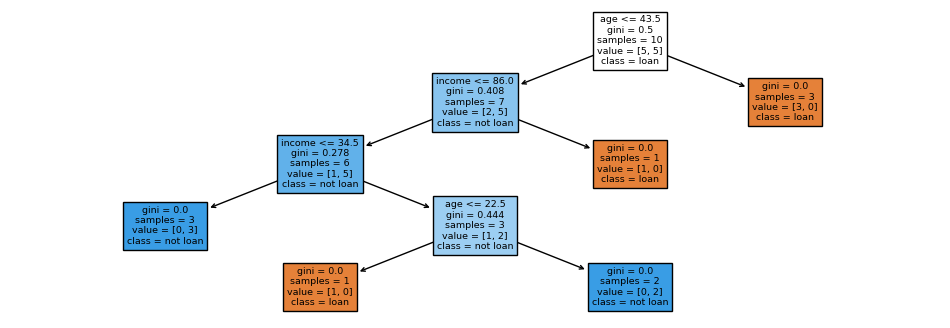

In [102]:
dt = tree.DecisionTreeClassifier(random_state=42)
dt.fit(X, y)

fig = plt.figure(figsize=(12, 4))
tree_graph = tree.plot_tree(
    decision_tree=dt, 
    feature_names=X.columns, 
    class_names=['loan', 'not loan'], 
    filled=True, 
    impurity=True
);

Ограничение максимальной глубины дерева (параметр max_depth)

По умолчанию глубина дерева не ограничена. Помните, что ограничение глубины дерева решений является основным методом борьбы с его переобучением.

В качестве примера ограничим глубину нашего дерева решений до 3:

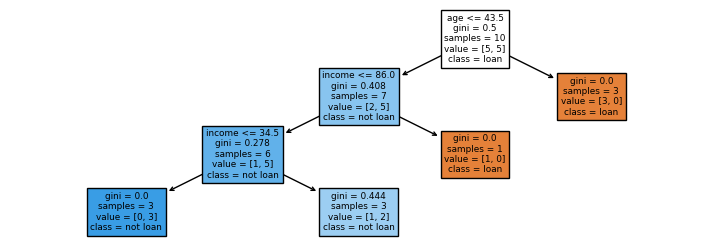

In [107]:
dt = tree.DecisionTreeClassifier(
    max_depth=3, 
    random_state=42
)
dt.fit(X, y)


fig = plt.figure(figsize=(9, 3))
tree_graph = tree.plot_tree(
    decision_tree=dt, 
    feature_names=X.columns, 
    class_names=['loan', 'not loan'], 
    filled=True, 
    impurity=True
);

Ограничение максимального количества листьев в дереве (параметр max_leaf_node)


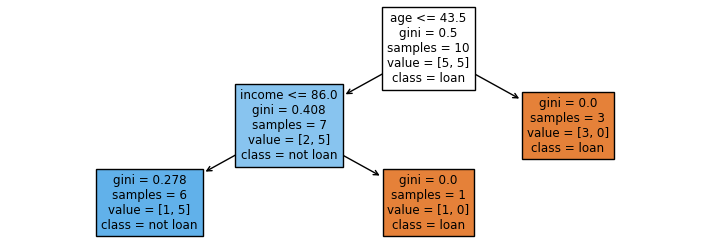

In [106]:
dt = tree.DecisionTreeClassifier(
    max_leaf_nodes=3, 
    random_state=42
)
dt.fit(X, y)


fig = plt.figure(figsize=(9, 3))
tree_graph = tree.plot_tree(
    decision_tree=dt, 
    feature_names=X.columns, 
    class_names=['loan', 'not loan'], 
    filled=True, 
    impurity=True
);

Ограничение на минимальное количество объектов, при которых допускается ветвление дерева (параметр min_samples_split)

Для примера обучим дерево решений с параметром ```min_samples_split = 6```:


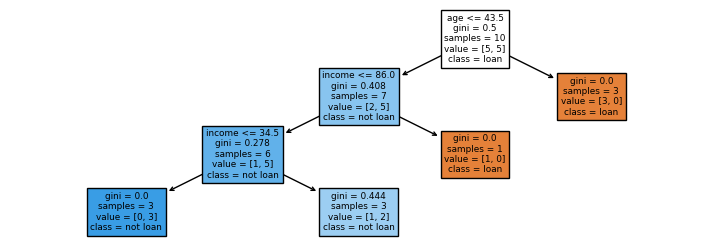

In [110]:
dt = tree.DecisionTreeClassifier(
    min_samples_split=6, 
    random_state=42
)
dt.fit(X, y)

fig = plt.figure(figsize=(9, 3))
tree_graph = tree.plot_tree(
    decision_tree=dt, 
    feature_names=X.columns, 
    class_names=['loan', 'not loan'], 
    filled=True, 
    impurity=True
);

Ограничение на минимальное количество объектов, необходимых для создания листа (параметр min_samples_leaf)

Посмотрим на примере, как работает этот критерий. Обучим дерево решений с параметром min_samples_leaf=3:

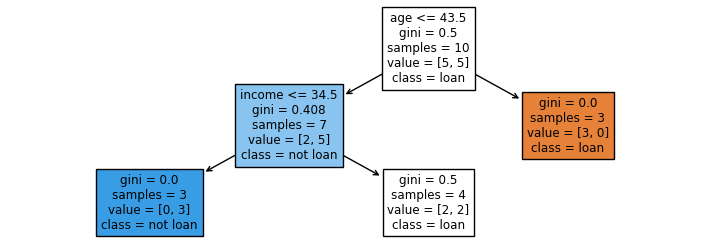

In [112]:
dt = tree.DecisionTreeClassifier(
    min_samples_leaf=3, 
    random_state=42
)
dt.fit(X, y)

fig = plt.figure(figsize=(9, 3))
tree_graph = tree.plot_tree(
    decision_tree=dt, 
    feature_names=X.columns, 
    class_names=['loan', 'not loan'], 
    filled=True, 
    impurity=True
);

Давайте адаптируем наш метод построения дерева решений и введём новое ограничение на максимальную глубину дерева: в функции stop_criterion() и build_decision_tree() добавим параметр max_depth, а также счётчик глубины рекурсии depth:

In [113]:
def stopping_criterion(X, y, criterion, max_depth=None, depth=0):
    if max_depth is None:
        return (criterion(y) == 0) 
    else:
        return (criterion(y) == 0) or (depth > max_depth)
    
def build_decision_tree(X, y, criterion, max_depth=None, depth=0):
    depth += 1
    if stopping_criterion(X, y, criterion, max_depth, depth):
        value = create_leaf_prediction(y)
        node = Node(
            value=value, 
            impurity=criterion(y), 
            samples=y.size,
            is_leaf=True
        )
    else:
        split_params = best_split(X, y, criterion=entropy)
        X_left, y_left, X_right, y_right = split(X, y, split_params)
        left = build_decision_tree(X_left, y_left, criterion, max_depth, depth)
        right = build_decision_tree(X_right, y_right, criterion, max_depth, depth)       
        node = Node(
            left=left, right=right, 
            split_params=split_params, 
            impurity=criterion(y), 
            samples=y.size
        )
    return node

In [114]:
# Строим дерево решений с ограничением глубины и выводим его на экран
decision_tree = build_decision_tree(X, y, criterion=entropy, max_depth=2)
print_decision_tree(decision_tree)

    feature_0 <= 43.500:
       feature_1 <= 86.000:
          class: 1
       feature_1 > 86.000:
          class: 0
    feature_0 > 43.500:
       class: 0


## 6/10   Алгоритм CART: значимость признаков


Реализуем функцию ```calculate_feature_importances()``` для расчёта относительных значимостей признаков. Она будет принимать на вход обученное дерево решений. Также у неё будет аргумент по умолчанию — массив из значимостей feature_importances. Так как функция будет рекурсивной, то при первом запуске массив нужно проинициализировать нулями.

Далее, до тех пор пока не «упрёмся» в листья, будем считать прирост информации для признака, записанного в вершине, и заносить результат в массив, затем рекурсивно проделывать то же самое для потомков. После окончания рекурсии образуется массив ```feature_importances```, в котором будут лежать суммарные приросты информации по каждому из признаков. Чтобы получить относительную значимость признаков, нужно будет разделить массив на число наблюдений, а затем нормировать на сумму.

In [115]:
def calculate_feature_importances(node, feature_importance=None):
    if feature_importance is None:
        feature_importance = np.zeros(X.shape[1])
    if node.value is None:
        j = node.split_params[0]
        feature_importance[j] += node.impurity * node.samples - \
                                 node.left.impurity * node.left.samples - \
                                 node.right.impurity * node.right.samples
        calculate_feature_importances(node.left, feature_importance)
        calculate_feature_importances(node.right, feature_importance)
    feature_importance /= node.samples
    feature_importance /= feature_importance.sum()
    return feature_importance

Протестируем функцию на нашем «игрушечном» датасете о кредитах:


In [117]:
# Создаём обучающую выборку
data = pd.DataFrame({
    'age': [17, 64, 18, 20, 38, 49, 55, 25, 29, 31],
    'income': [25, 80, 22, 36, 37, 59, 74, 70, 33, 102],
    'loan': [1, 0, 1, 0, 1, 0, 0, 1, 1, 0]
})
X = data[['age', 'income']]
y = data['loan'] 
# Строим дерево решений и выводим его на экран
decision_tree = build_decision_tree(X, y, entropy)
# Вычисляем значения информативности признаков
print(calculate_feature_importances(decision_tree))
# [0.78582905 0.21417095]

[0.78582905 0.21417095]


Ещё один способ проверить себя — свериться с результатами библиотеки sklearn:


In [118]:
# Создаём модель дерева решений и обучаем её
dt = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий информативности
    random_state=1000 #генератор случайных чисел
)
dt.fit(X, y)
# Вычисляем значения информативности признаков
print(dt.feature_importances_)
# [0.78582905 0.21417095]

[0.78582905 0.21417095]
